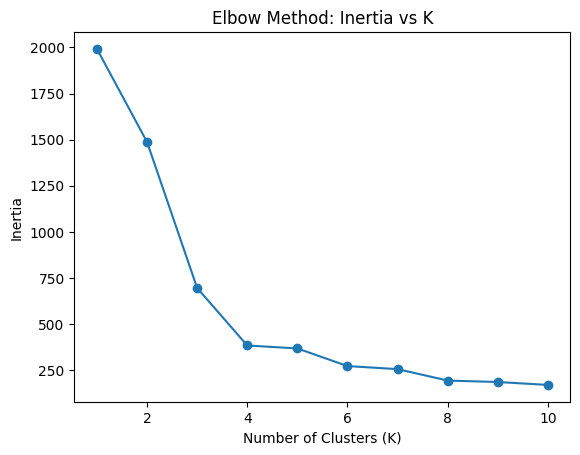

       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
label                                                                   
0             43.878302        19.111321         194.764151  4006.603774
1             45.563793        14.237931         212.706897  4679.741379
2             40.217757        17.611215         189.046729  3419.158879
3             49.473770        15.718033         221.540984  5484.836066


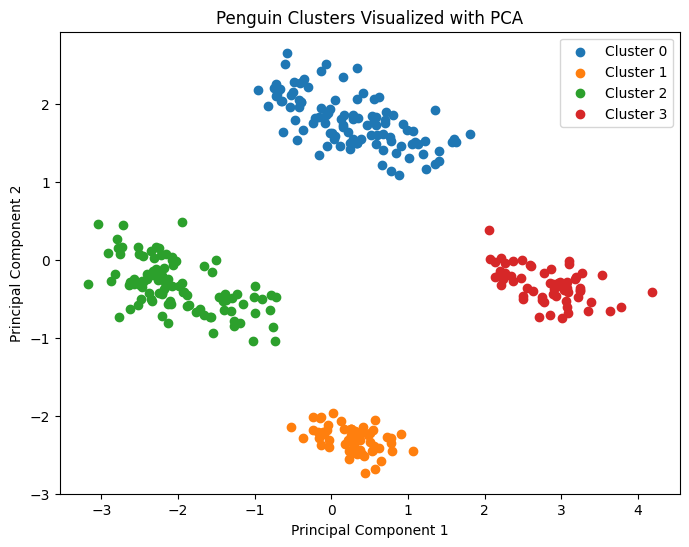

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
penguins_df = pd.read_csv('penguins.csv')

# Encode categorical variables
penguins_df_encoded = pd.get_dummies(penguins_df, columns=['sex'])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(penguins_df_encoded)
penguins_preprocessed = pd.DataFrame(X_scaled, columns=penguins_df_encoded.columns)

#Find optimal number of clusters for k-means clustering
inertia = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(penguins_preprocessed)
  inertia.append(kmeans.inertia_)

#Show plot to find best K value
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Inertia vs K')
plt.show()

#Run the k-means clustering algorithm with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(penguins_preprocessed)
penguins_df["label"] = kmeans.labels_

# Compute mean feature values for each cluster
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm','body_mass_g', 'label']
stat_penguins = penguins_df[numeric_columns].groupby("label").mean()
print(stat_penguins)

# Reduce high-dimensional data to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(penguins_preprocessed)

# Plot clusters in PCA space
plt.figure(figsize=(8,6))
cluster_names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
}
for cluster in range(4):
    plt.scatter(
        X_pca[kmeans.labels_ == cluster, 0],
        X_pca[kmeans.labels_ == cluster, 1],
        label=f"Cluster {cluster}"
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Penguin Clusters Visualized with PCA")
plt.legend()
plt.show()


In [8]:
penguins_df.isnull().sum()

,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
